# Car Market Trends Analysis with CarDekho Data

**VOIS for Tech — Data Analytics Internship**
**Minor Project (DIY PROJECT-4)**

---

**Dataset:** CarDekho Vehicle Dataset (provided by VOIS)
**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn


## Project Objective

The objective of this project is to analyze the CarDekho used-vehicle dataset to uncover
meaningful patterns and trends in the used-vehicle market. Specifically, the analysis aims to:

- Understand the structure and quality of the dataset.
- Study the distribution of manufacturing year, selling price, and kilometers driven.
- Identify the most common fuel types, transmission types, seller types, and ownership categories.
- Examine how selling price is influenced by year, kilometers driven, fuel type, transmission,
  and ownership.
- Identify the most popular models and, where reliably possible, brands.
- Discover correlations between numerical variables.
- Summarize key findings that could support buyers, sellers, dealers, and market analysts.


## Problem Statement

The used-vehicle market is influenced by many factors — age of the vehicle, kilometers driven,
fuel type, transmission type, and ownership history — all of which affect the resale (selling)
price. Buyers and sellers often lack clear, data-driven insight into how these factors interact.

This project uses exploratory data analysis (EDA) and statistical techniques on the CarDekho
dataset to quantify these relationships and present clear, evidence-based insights into used
vehicle pricing trends.


## Dataset Description

The dataset used in this project is the **CarDekho vehicle dataset** provided by VOIS. It
contains listings of used vehicles along with attributes relevant to pricing and market
analysis.

The dataset (as uploaded) contains the following columns:

| Column | Description |
|---|---|
| `Car_Name` | Name/model of the vehicle as listed |
| `Year` | Manufacturing year of the vehicle |
| `Selling_Price` | Price at which the vehicle is being sold (in Lakhs INR) |
| `Present_Price` | Current ex-showroom price of the vehicle when new (in Lakhs INR) |
| `Kms_Driven` | Total kilometers driven |
| `Fuel_Type` | Fuel type of the vehicle (Petrol / Diesel / CNG) |
| `Seller_Type` | Type of seller (Dealer / Individual) |
| `Transmission` | Transmission type (Manual / Automatic) |
| `Owner` | Number of previous owners (0 = first owner) |

## 1. Import Required Libraries

We import only the libraries required for this analysis: Pandas and NumPy for data handling,
and Matplotlib/Seaborn for visualization. No paid APIs, databases, or unnecessary libraries
are used.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Loading the Dataset


In [3]:
import os
import glob

df = None
csv_path = None

# Try Google Colab file upload
try:
    from google.colab import files
    print("Google Colab detected. Please upload the CarDekho CSV file.")
    uploaded = files.upload()
    if len(uploaded) > 0:
        csv_path = list(uploaded.keys())[0]
except ImportError:
    print("Not running in Google Colab. Will look for a local CSV file instead.")

# Fallback: look for a CSV file in the current directory
if csv_path is None:
    candidates = glob.glob("*.csv")
    if "car_data.csv" in candidates:
        csv_path = "car_data.csv"
    elif len(candidates) > 0:
        csv_path = candidates[0]

if csv_path is None:
    raise FileNotFoundError(
        "No CSV file found. Please upload the CarDekho CSV file and re-run this cell."
    )

df = pd.read_csv(csv_path)
print(f"Loaded dataset from: {csv_path}")
print(f"Shape: {df.shape}")


Google Colab detected. Please upload the CarDekho CSV file.


Saving 1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv to 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv
Loaded dataset from: 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv
Shape: (301, 9)


## 3. Doing Initial Dataset Inspection

In [4]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())


Dataset Shape: (301, 9)
Number of Rows: 301
Number of Columns: 9

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [13]:
print("Getting the information of about datatypes present in the data\n");

df.info()

Getting the information of about datatypes present in the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [16]:
print("Getting the top five rows of the dataset\n");

df.head()

Getting the top five rows of the dataset



,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [17]:
print("Getting the last five rows of the dataset\n");

df.tail()

Getting the last five rows of the dataset



,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [19]:
print("Inspecting 5 random samples\n");

df.sample(5, random_state=42)

Inspecting 5 random samples



,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
177,Honda Activa 125,2016,0.35,0.57,24000,Petrol,Individual,Automatic,0
289,city,2016,10.11,13.60,10980,Petrol,Dealer,Manual,0
228,verna,2012,4.95,9.40,60000,Diesel,Dealer,Manual,0
198,Bajaj Discover 125,2011,0.15,0.57,35000,Petrol,Individual,Manual,1
60,corolla altis,2013,6.95,18.61,40001,Petrol,Dealer,Manual,0


In [21]:
print("Getting to know about the dataset in depth\n");

df.describe(include='all').T

Getting to know about the dataset in depth



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [23]:
print("Checking missing values per column:\n")
print(df.isnull().sum())

Checking missing values per column:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [27]:
print("Checking Number of duplicate rows if any:", df.duplicated().sum())
print("\n")
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())


Checking Number of duplicate rows if any: 2




,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


### Insights gathered from Initial Inspection

- The dataset contains vehicle listings with numerical columns (year, prices, kilometers
  driven, owner count) and categorical columns (fuel type, seller type, transmission).
- The counts of missing values and duplicate rows above determine what cleaning steps are
  needed in the next section.


## 4. Data Cleaning

Since, cleaning process can get corrupted or wronh, I am preserving the original as `df_original` and performing all the cleaning on its copy, `df_toclean`, so the raw data is always there as a backup.

Cleaning steps performed:

1. Removing exact duplicate rows, if any — duplicate listings would otherwise bias frequency, counts and averages.
2. Verifying and correcting data types for numerical columns if any.
3. Checking for impossible/suspicious values such as `negative prices` or `negative kilometers driven`, `manufacturing years outside a realistic range`.
4. Checking categorical columns for inconsistent labels such as extra whitespaces or inconsistent capitalization.
5. Droping any column that is entirely empty or provides no analytical value.


In [28]:
# Preserving the original dataframe for backup
df_original = df.copy()

# Creating a working copy for cleaning
df_toclean = df.copy()

shape_before = df_toclean.shape
print("Shape before cleaning:", shape_before)


Shape before cleaning: (301, 9)


### 4.1 Removing Duplicate Rows

Here we remove exact duplicates while keeping the first occurrence.


In [38]:
duplicates_before = df_toclean.duplicated().sum()
df_toclean = df_toclean.drop_duplicates().reset_index(drop=True)
duplicates_after = df_toclean.duplicated().sum()

print(f"Duplicate rows removed: {duplicates_before}")
print(f"Duplicate rows remaining: {duplicates_after}")
print(f"Shape after removing duplicates: {df_toclean.shape}")


Duplicate rows removed: 0
Duplicate rows remaining: 0
Shape after removing duplicates: (299, 9)


### 4.2 Standardizing Text/Categorical Columns


In [34]:
text_columns = df_toclean.select_dtypes(include='object').columns.tolist()
print("Text columns found:", text_columns)

for col in text_columns:
    df_toclean[col] = df_toclean[col].astype(str).str.strip()

print("\nWhitespace stripped from text columns.")


Text columns found: ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']

Whitespace stripped from text columns.


### 4.3 Checking Numerical Columns for Suspicious/Impossible Values

We only remove rows if genuinely impossible values are found. We do not remove valid but simply "high" or "low" values, since those are legitimate market data points (outliers), not errors.


In [42]:
import datetime
current_year = datetime.datetime.now().year

issues = {}

if 'Year' in df_toclean.columns:
    invalid_year = df_toclean[(df_toclean['Year'] > current_year) | (df_toclean['Year'] < 1980)]
    issues['Year out of realistic range'] = len(invalid_year)

if 'Kms_Driven' in df_toclean.columns:
    invalid_kms = df_toclean[df_toclean['Kms_Driven'] < 0]
    issues['Negative Kms_Driven'] = len(invalid_kms)

if 'Selling_Price' in df_toclean.columns:
    invalid_sp = df_toclean[df_toclean['Selling_Price'] <= 0]
    issues['Non-positive Selling_Price'] = len(invalid_sp)

if 'Present_Price' in df_toclean.columns:
    invalid_pp = df_toclean[df_toclean['Present_Price'] <= 0]
    issues['Non-positive Present_Price'] = len(invalid_pp)

for k, v in issues.items():
    print(f"{k}: {v} row(s)")

# Removing only genuinely impossible rows, if any
rows_to_drop = set()
if 'Year' in df_toclean.columns:
    rows_to_drop.update(df_toclean[(df_toclean['Year'] > current_year) | (df_toclean['Year'] < 1980)].index)
if 'Kms_Driven' in df_toclean.columns:
    rows_to_drop.update(df_toclean[df_toclean['Kms_Driven'] < 0].index)
if 'Selling_Price' in df_toclean.columns:
    rows_to_drop.update(df_toclean[df_toclean['Selling_Price'] <= 0].index)
if 'Present_Price' in df_toclean.columns:
    rows_to_drop.update(df_toclean[df_toclean['Present_Price'] <= 0].index)

if len(rows_to_drop) > 0:
    df_toclean = df_toclean.drop(index=list(rows_to_drop)).reset_index(drop=True)
    print(f"\nRemoved {len(rows_to_drop)} row(s) with impossible values.")
else:
    print("\nNo impossible values found. No rows removed at this step.")


Year out of realistic range: 0 row(s)
Negative Kms_Driven: 0 row(s)
Non-positive Selling_Price: 0 row(s)
Non-positive Present_Price: 0 row(s)

No impossible values found. No rows removed at this step.


### 4.4 Handling Missing Values

Here we are going to re-check missing values on the cleaned dataframe. If any column has missing values, we handle them based on the column type: numerical columns are imputed with the median (robust to outliers), and categorical columns are imputed with the mode, or the rows are dropped if the proportion of missing data in that column is very small. If no missing values are present,
this step confirms that and no imputation is necessary.


In [41]:
missing_counts = df_toclean.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

if len(missing_counts) == 0:
    print("No missing values found in the dataset. No imputation needed.")
else:
    print("Missing values found:\n", missing_counts)
    for col in missing_counts.index:
        if df_toclean[col].dtype in ['int64', 'float64']:
            median_val = df_toclean[col].median()
            df_toclean[col] = df_toclean[col].fillna(median_val)
            print(f"Filled missing values in numeric column '{col}' with median ({median_val}).")
        else:
            mode_val = df_toclean[col].mode()[0]
            df_toclean[col] = df_toclean[col].fillna(mode_val)
            print(f"Filled missing values in categorical column '{col}' with mode ('{mode_val}').")


No missing values found in the dataset. No imputation needed.


### 4.5 Data Type Verification

Confirming the numerical columns if stored as numeric types or strings, and correcting if required.


In [44]:
numeric_candidates = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
for col in numeric_candidates:
    if col in df_toclean.columns and df_toclean[col].dtype == 'object':
        df_toclean[col] = pd.to_numeric(df_toclean[col], errors='coerce')
        print(f"Converted '{col}' to numeric type.")

print("\nFinal data types:\n")
print(df_toclean.dtypes)



Final data types:

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


### 4.6 Feature Engineering: Car Age

Calculating the age of the car for a more intuitive market-trend study.

In [45]:
if 'Year' in df_toclean.columns:
    df_toclean['Car_Age'] = current_year - df_toclean['Year']
    print("Added 'Car_Age' column (current_year - Year).")
    df_toclean[['Year', 'Car_Age']].head()


Added 'Car_Age' column (current_year - Year).


### 4.7 Cleaning Summary


In [50]:
#Converting df_toclean to df_clean after cleaning.
df_clean = df_toclean

shape_after = df_clean.shape

print("Shape before cleaning:", shape_before)
print("Shape after cleaning:", shape_after)
print("Remaining missing values:", df_clean.isnull().sum().sum())
print("Remaining duplicate rows:", df_clean.duplicated().sum())
print("\nFinal data types:\n")
print(df_clean.dtypes)


Shape before cleaning: (301, 9)
Shape after cleaning: (299, 10)
Remaining missing values: 0
Remaining duplicate rows: 0

Final data types:

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
Car_Age            int64
dtype: object


## 5. Exploratory Data Analysis (EDA)

Now, we will be deeply exploring the cleaned dataset.



### 5.1 Numerical Column Analysis

Starting with computing the mean, median, mode, min, max, standard deviation and quarties for the significant numerical columns.

In [51]:
numerical_cols = [c for c in ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
                   if c in df_clean.columns]

numerical_summary = df_clean[numerical_cols].agg(['mean', 'median', 'min', 'max', 'std']).T
numerical_summary['Q1'] = df_clean[numerical_cols].quantile(0.25)
numerical_summary['Q3'] = df_clean[numerical_cols].quantile(0.75)
numerical_summary


,mean,median,min,max,std,Q1,Q3
Year,2013.615385,2014.00,2003.00,2018.0,2.896868,2012.00,2016.00
Selling_Price,4.589632,3.51,0.10,35.0,4.984240,0.85,6.00
Present_Price,7.541037,6.10,0.32,92.6,8.567887,1.20,9.84
Kms_Driven,36916.752508,32000.00,500.00,500000.0,39015.170352,15000.00,48883.50
Owner,0.043478,0.00,0.00,3.0,0.248720,0.00,0.00
Car_Age,12.384615,12.00,8.00,23.0,2.896868,10.00,14.00


### 5.2 Categorical Column Analysis

Computing the frequency of the data for the significant categorical columns, such as `Fuel_Type`, `Seller_Type`, `Transmission` & `Owner`.

In [61]:
categorical_cols = [c for c in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
                    if c in df_clean.columns]

for col in categorical_cols:
    counts = df_clean[col].value_counts()
    percentages = df_clean[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    })

    print(f"\n------------ {col} ------------")
    display(summary)
    print("\n")  # Gap after each table



------------ Fuel_Type ------------


,Count,Percentage (%)
Fuel_Type,,
Petrol,239,79.93
Diesel,58,19.40
CNG,2,0.67





------------ Seller_Type ------------


,Count,Percentage (%)
Seller_Type,,
Dealer,193,64.55
Individual,106,35.45





------------ Transmission ------------


,Count,Percentage (%)
Transmission,,
Manual,260,86.96
Automatic,39,13.04





------------ Owner ------------


,Count,Percentage (%)
Owner,,
0,288,96.32
1,10,3.34
3,1,0.33


### 5.3 Most Common Car Models

`Car_Name` in this dataset generally contains the **model name** of the vehicle (e.g., `swift`,
`ciaz`, `fortuner`), while a smaller subset of entries (two-wheelers) do include a manufacturer
name (e.g., `Royal Enfield Classic 350`, `KTM RC200`). We therefore analyze popularity primarily
by the **model** , which is reliably available for every row.

In [62]:
top_models = df_clean['Car_Name'].value_counts().head(15)
top_models


,count
Car_Name,
city,26
corolla altis,16
verna,14
brio,10
fortuner,10
ciaz,9
i20,9
innova,9
grand i10,8


## 6. Brand Extraction (Where Reliable)

**Method and limitation:** Inspecting the unique values of `Car_Name` shows that most
four-wheeler entries contain **only the model name** (e.g., `swift`, `ciaz`, `wagon r`) without
a manufacturer prefix, so the brand cannot be reliably inferred. However, some entries — mostly
two-wheelers — do begin with recognizable manufacturer names (e.g., `Royal Enfield`, `KTM`,
`Bajaj`, `Honda`, `TVS`, `Yamaha`).

To avoid unreliable assumptions, we assign a brand only when the `Car_Name` clearly starts with
a known manufacturer name. All other rows are labeled `"Model only (brand not available)"` and
excluded from brand-level price comparisons.

In [63]:
known_brands = [
    "Royal Enfield", "Hyosung", "Mahindra", "Bajaj", "KTM", "UM",
    "Honda", "Yamaha", "Suzuki", "TVS", "Hero"
]
# Sort longest-first so multi-word brands are matched before shorter substrings
known_brands_sorted = sorted(known_brands, key=len, reverse=True)

def extract_brand(name):
    for brand in known_brands_sorted:
        if name.strip().lower().startswith(brand.lower()):
            return brand
    return "Model only (brand not available)"

df_clean['Brand'] = df_clean['Car_Name'].apply(extract_brand)

brand_counts = df_clean['Brand'].value_counts()
brand_counts


,count
Brand,
Model only (brand not available),201
Bajaj,25
Honda,17
Royal Enfield,17
Hero,15
Yamaha,8
TVS,8
KTM,4
UM,1


The large majority of rows fall under **"Model only (brand not available)"**, confirming
that reliable brand-level analysis is only possible for a minority of the dataset (mostly
two-wheelers). Brand-level average-price comparisons below are therefore restricted to rows
with an identified brand, and should be read as illustrative rather than representative of the
whole market.


In [65]:
df_branded = df_clean[df_clean['Brand'] != "Model only (brand not available)"]
print(f"Rows with identifiable brand: {len(df_branded)} out of {len(df_clean)}")

if len(df_branded) > 0:
    brand_avg_price = df_branded.groupby('Brand')['Selling_Price'].mean().sort_values(ascending=False)
    print("\nAverage Selling Price by identified brand (in Lakhs INR):")
    for brand, price in brand_avg_price.items():
        print(f"{brand:20s} ₹{price:.2f} Lakhs")

Rows with identifiable brand: 98 out of 299

Average Selling Price by identified brand (in Lakhs INR):
UM                   ₹1.70 Lakhs
Hyosung              ₹1.35 Lakhs
KTM                  ₹1.34 Lakhs
Mahindra             ₹1.15 Lakhs
Royal Enfield        ₹1.14 Lakhs
Yamaha               ₹0.58 Lakhs
Bajaj                ₹0.53 Lakhs
TVS                  ₹0.46 Lakhs
Honda                ₹0.44 Lakhs
Hero                 ₹0.36 Lakhs
Suzuki               ₹0.25 Lakhs


## 7. Statistical Analysis

Now, we will be taking a more closer look at central tendency and spread for the most important numerical
variable, `Selling_Price`, and examine how manufacturing year relates to it.


In [66]:
print("Selling Price Statistics (in Lakhs INR):")
print(f"Mean:   {df_clean['Selling_Price'].mean():.2f}")
print(f"Median: {df_clean['Selling_Price'].median():.2f}")
print(f"Std Dev:{df_clean['Selling_Price'].std():.2f}")
print(f"Min:    {df_clean['Selling_Price'].min():.2f}")
print(f"Max:    {df_clean['Selling_Price'].max():.2f}")
print(f"25th percentile: {df_clean['Selling_Price'].quantile(0.25):.2f}")
print(f"75th percentile: {df_clean['Selling_Price'].quantile(0.75):.2f}")


Selling Price Statistics (in Lakhs INR):
Mean:   4.59
Median: 3.51
Std Dev:4.98
Min:    0.10
Max:    35.00
25th percentile: 0.85
75th percentile: 6.00


In [67]:
# Highest and lowest priced vehicles
print("Top 5 highest-priced listings:")
display(df_clean.nlargest(5, 'Selling_Price')[['Car_Name', 'Year', 'Selling_Price', 'Fuel_Type', 'Transmission']])

print("\nTop 5 lowest-priced listings:")
display(df_clean.nsmallest(5, 'Selling_Price')[['Car_Name', 'Year', 'Selling_Price', 'Fuel_Type', 'Transmission']])


Top 5 highest-priced listings:


,Car_Name,Year,Selling_Price,Fuel_Type,Transmission
85,land cruiser,2010,35.0,Diesel,Manual
63,fortuner,2017,33.0,Diesel,Automatic
62,fortuner,2015,23.5,Diesel,Automatic
50,fortuner,2015,23.0,Diesel,Automatic
81,innova,2017,23.0,Diesel,Automatic



Top 5 lowest-priced listings:


,Car_Name,Year,Selling_Price,Fuel_Type,Transmission
198,Bajaj Pulsar 150,2006,0.10,Petrol,Manual
197,Honda CB Shine,2007,0.12,Petrol,Manual
196,Bajaj Discover 125,2011,0.15,Petrol,Manual
195,Honda CB twister,2010,0.16,Petrol,Manual
194,Activa 3g,2008,0.17,Petrol,Automatic


## 8. Car Market Trend Analysis & Visualizations



### 8.1 Distribution of Selling Prices


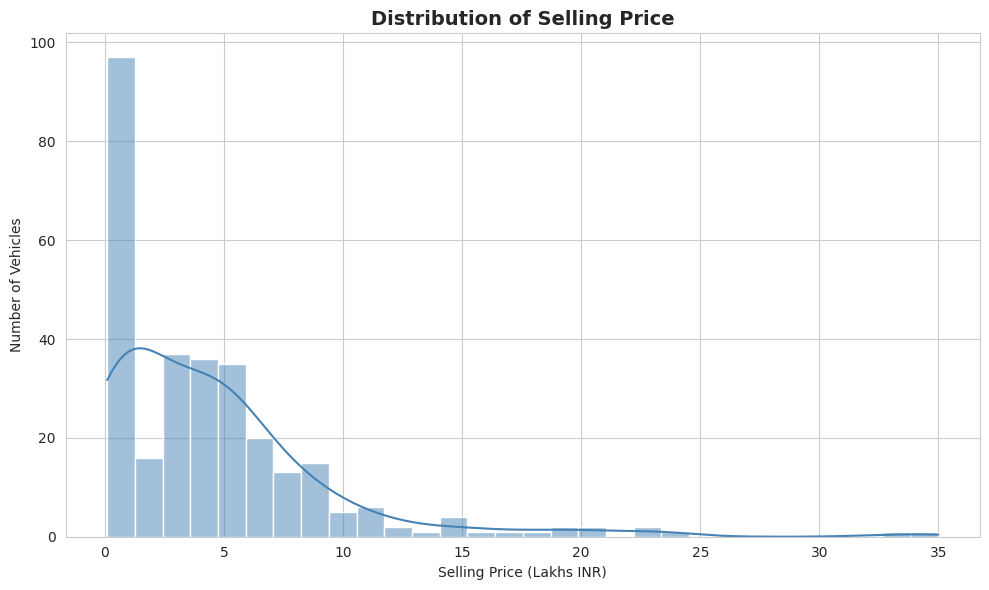

In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Selling_Price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs INR)')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()


**Observation:** The selling price distribution is right-skewed. Most of the vehicles are concentrated in the lower price range, while a smaller number of high-priced vehicles extend the distribution towards the right. This suggests that budget and mid-range vehicles make up most of the market, while premium vehicles are comparatively less common.

### 8.2 Number of Vehicles by Manufacturing Year


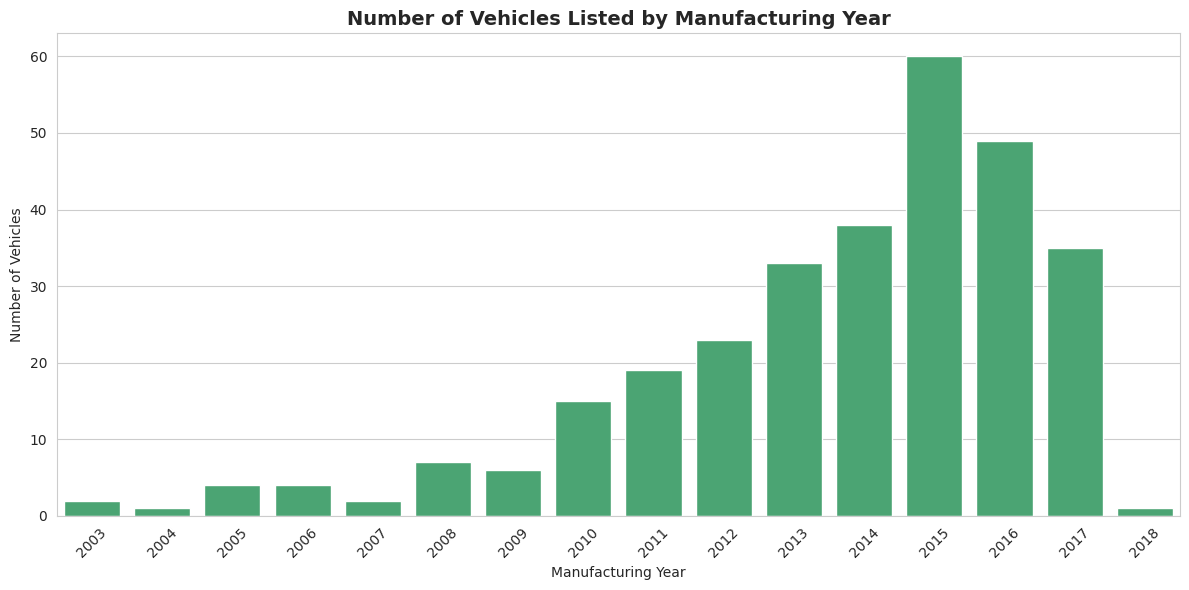

Year with the highest number of listings: 2015 (60 vehicles)


In [69]:
plt.figure(figsize=(12, 6))
year_counts = df_clean['Year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, color='mediumseagreen')
plt.title('Number of Vehicles Listed by Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Year with the highest number of listings: {year_counts.idxmax()} ({year_counts.max()} vehicles)")


**Observation:** Most of the listings are concentrated in the recent years, which shows that the platform has more relatively newer used vehicles compared to older ones. This suggests that sellers are more likely to list newer vehicles on the platform, while very old vehicles make up a smaller portion of the listings.

### 8.3 Vehicles by Fuel Type


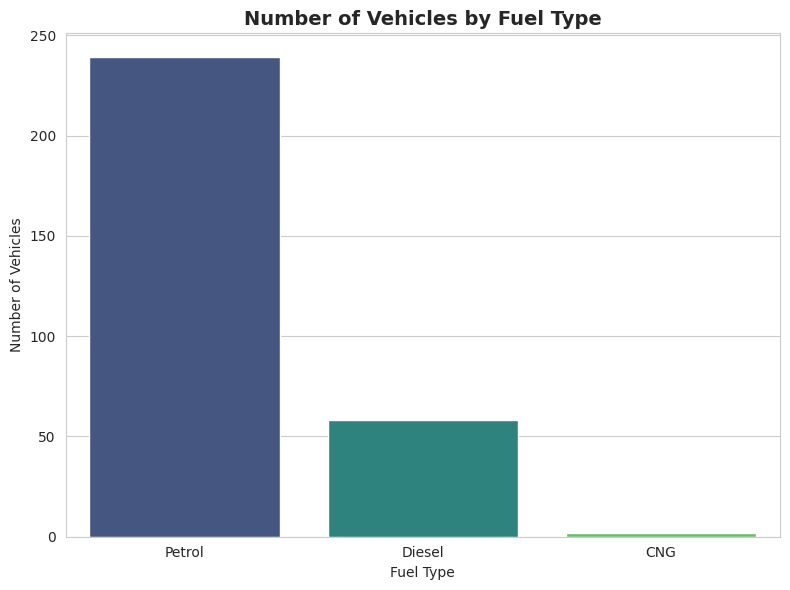

Most common fuel type: Petrol (239 vehicles, 79.9% of the dataset)


In [70]:
plt.figure(figsize=(8, 6))
fuel_counts = df_clean['Fuel_Type'].value_counts()
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette='viridis')
plt.title('Number of Vehicles by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()

print(f"Most common fuel type: {fuel_counts.idxmax()} ({fuel_counts.max()} vehicles, "
      f"{fuel_counts.max()/len(df_clean)*100:.1f}% of the dataset)")


**Observation:** One fuel type clearly dominates the listings, as shown by the value printed above. This indicates that this fuel type is more commonly preferred by vehicle owners in this market. On the other hand, vehicles with less common fuel types have fewer listings, so sellers may need to consider this difference while pricing and marketing them.

### 8.4 Vehicles by Transmission Type


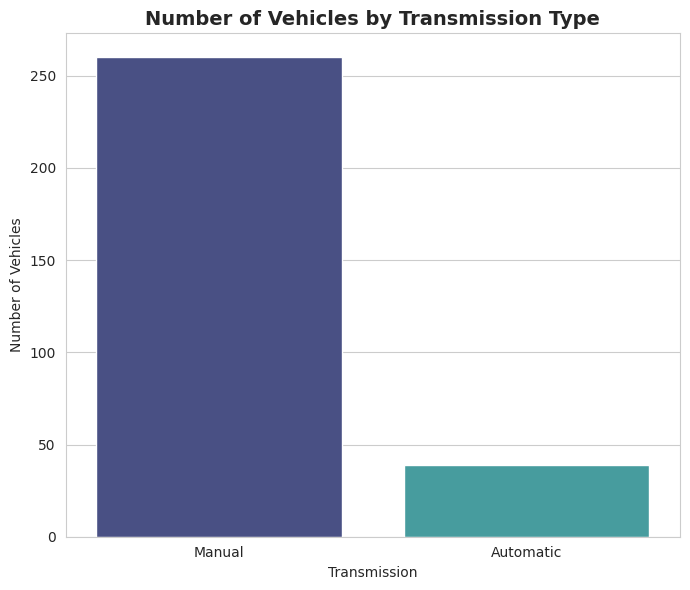

Most common transmission: Manual (87.0% of the dataset)


In [71]:
plt.figure(figsize=(7, 6))
trans_counts = df_clean['Transmission'].value_counts()
sns.barplot(x=trans_counts.index, y=trans_counts.values, palette='mako')
plt.title('Number of Vehicles by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()

print(f"Most common transmission: {trans_counts.idxmax()} "
      f"({trans_counts.max()/len(df_clean)*100:.1f}% of the dataset)")


**Observation:** Manual-transmission vehicles are far more common in the listings than
automatic ones, which is consistent with automatic vehicles historically being a smaller,
premium segment of the used market.


### 8.5 Vehicles by Seller Type


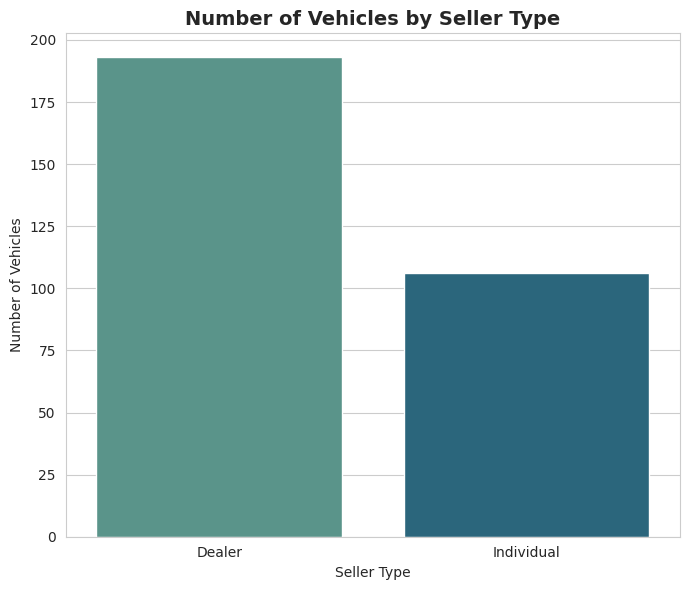

In [72]:
plt.figure(figsize=(7, 6))
seller_counts = df_clean['Seller_Type'].value_counts()
sns.barplot(x=seller_counts.index, y=seller_counts.values, palette='crest')
plt.title('Number of Vehicles by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()


**Observation:** The chart shows the distribution of vehicles listed by dealers and individual sellers. This helps us understand which seller category contributes more listings on the platform and provides useful context for comparing their price trends in the next analysis.

### 8.6 Vehicles by Ownership (Number of Previous Owners)


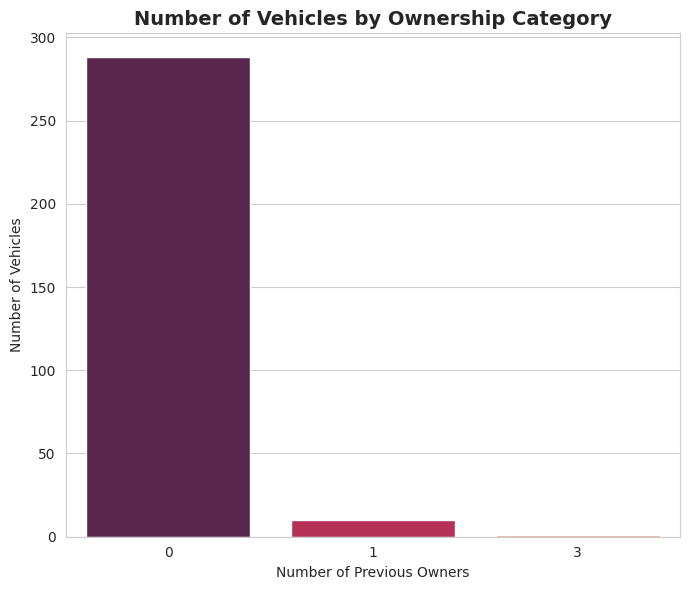

In [73]:
plt.figure(figsize=(7, 6))
owner_counts = df_clean['Owner'].value_counts().sort_index()
sns.barplot(x=owner_counts.index.astype(str), y=owner_counts.values, palette='rocket')
plt.title('Number of Vehicles by Ownership Category')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()


**Observation:** The majority of the listed vehicles are first-owner vehicles (Owner = 0). This indicates that most vehicles on the platform are being sold by their first owners, which can generally increase buyer confidence and may also contribute to higher resale values.

### 8.7 Selling Price vs. Manufacturing Year


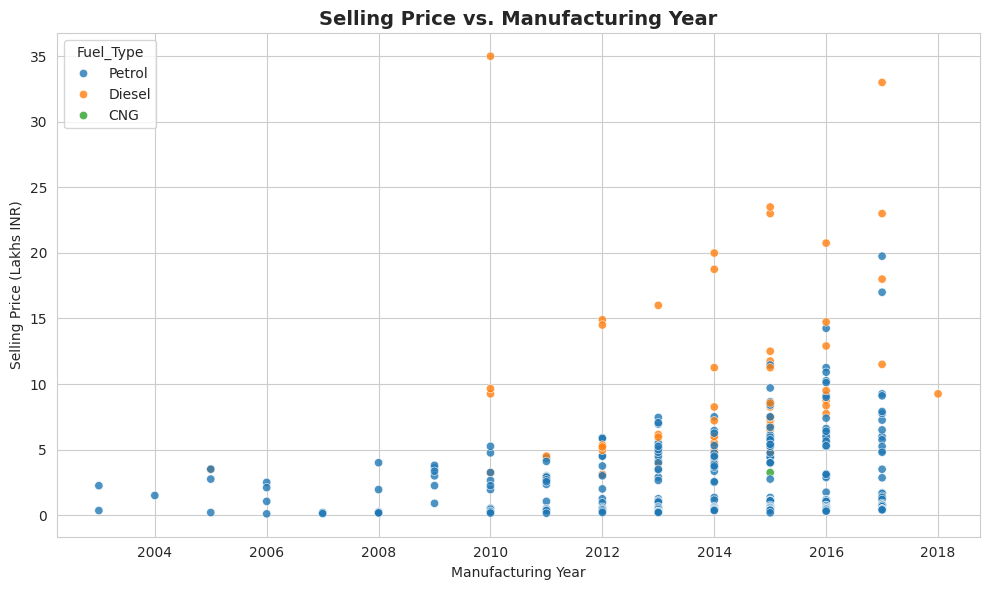

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Year', y='Selling_Price', hue='Fuel_Type', alpha=0.8)
plt.title('Selling Price vs. Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price (Lakhs INR)')
plt.tight_layout()
plt.show()


**Observation:** Selling price generally increases with the manufacturing year. This shows that newer vehicles tend to have higher resale prices, while older vehicles are usually priced lower due to depreciation over time.

### 8.8 Selling Price vs. Kilometers Driven


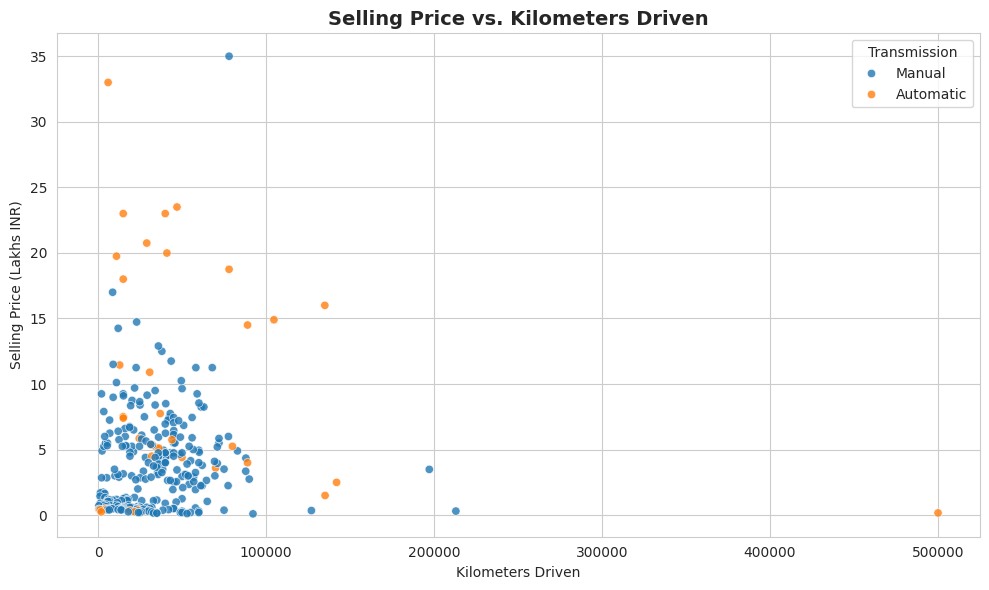

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Kms_Driven', y='Selling_Price', hue='Transmission', alpha=0.8)
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Lakhs INR)')
plt.tight_layout()
plt.show()


**Observation:** There is a general downward relationship between kilometers driven and selling price, although the relationship is not very strong. Vehicles with higher kilometers driven tend to have lower selling prices, which is expected as higher usage usually means more wear and less remaining usable life.

### 8.9 Average Selling Price by Fuel Type


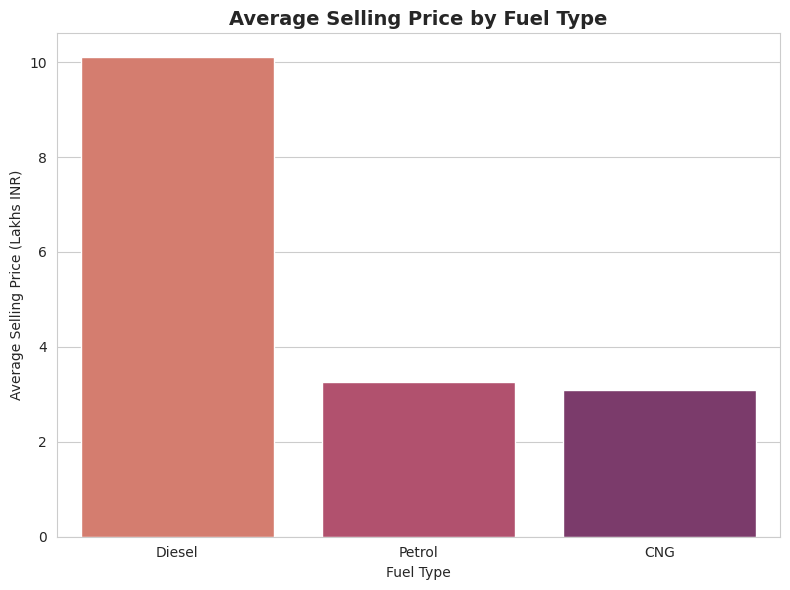

,Selling_Price
Fuel_Type,
Diesel,10.10
Petrol,3.26
CNG,3.10


In [76]:
plt.figure(figsize=(8, 6))
avg_price_fuel = df_clean.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_fuel.index, y=avg_price_fuel.values, palette='flare')
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (Lakhs INR)')
plt.tight_layout()
plt.show()

avg_price_fuel.round(2)


**Observation:** The average selling price varies across different fuel types, as shown in the chart/table above. This suggests that fuel type can have an impact on the selling price and should be considered when estimating the fair price of a vehicle.

### 8.10 Average Selling Price by Transmission Type


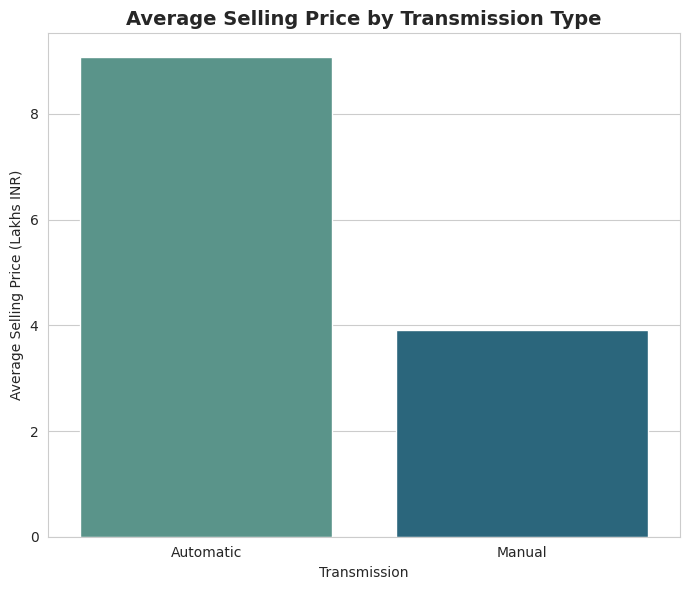

,Selling_Price
Transmission,
Automatic,9.07
Manual,3.92


In [77]:
plt.figure(figsize=(7, 6))
avg_price_trans = df_clean.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_trans.index, y=avg_price_trans.values, palette='crest')
plt.title('Average Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price (Lakhs INR)')
plt.tight_layout()
plt.show()

avg_price_trans.round(2)


**Observation:** Automatic-transmission vehicles have a noticeably higher average selling price compared to manual vehicles. This suggests that automatic vehicles are generally positioned in a higher-priced segment, which can be linked to their availability in higher-end or premium variants.

### 8.11 Average Selling Price by Ownership


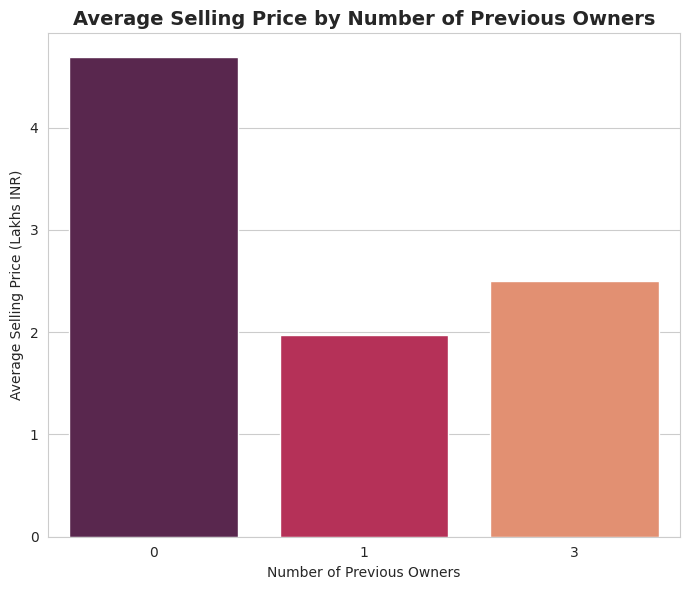

,Selling_Price
Owner,
0,4.69
1,1.97
3,2.50


In [78]:
plt.figure(figsize=(7, 6))
avg_price_owner = df_clean.groupby('Owner')['Selling_Price'].mean().sort_index()
sns.barplot(x=avg_price_owner.index.astype(str), y=avg_price_owner.values, palette='rocket')
plt.title('Average Selling Price by Number of Previous Owners')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Average Selling Price (Lakhs INR)')
plt.tight_layout()
plt.show()

avg_price_owner.round(2)


**Observation:** The average selling price generally decreases as the number of previous owners increases. This suggests that first-owner vehicles tend to have higher resale values, while vehicles with more previous owners are usually priced lower.

### 8.12 Top Models by Number of Listings


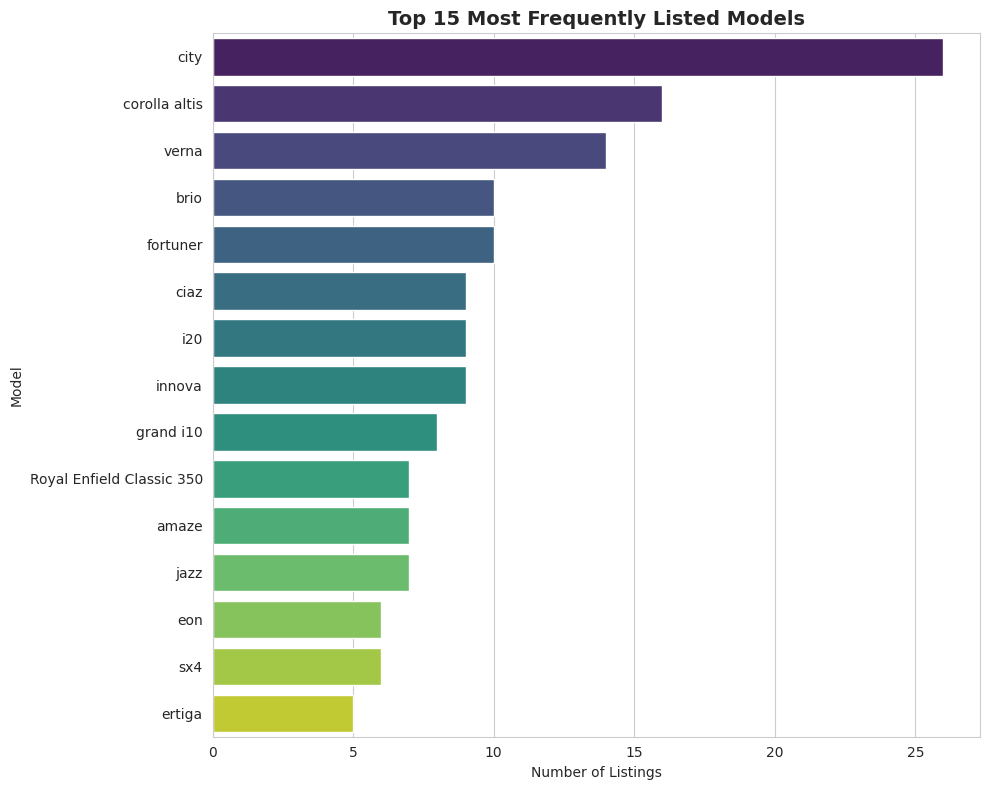

In [79]:
plt.figure(figsize=(10, 8))
top_models_plot = df_clean['Car_Name'].value_counts().head(15)
sns.barplot(x=top_models_plot.values, y=top_models_plot.index, palette='viridis')
plt.title('Top 15 Most Frequently Listed Models')
plt.xlabel('Number of Listings')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


**Observation:** A small number of vehicle models make up a large portion of the total listings. This suggests that these models are more commonly owned and resold in this market, while the remaining models have comparatively fewer listings.

### 8.13 Average Selling Price by Identified Brand

(Restricted to the subset of rows where a manufacturer brand could be reliably identified —
refer Section 6.)


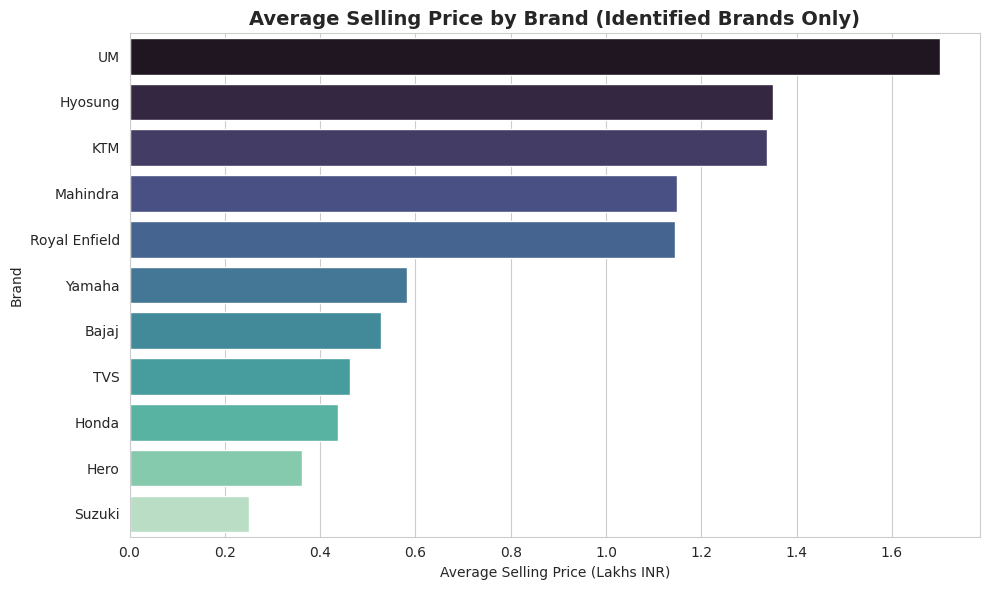

In [80]:
if len(df_branded) > 0:
    plt.figure(figsize=(10, 6))
    brand_avg_sorted = df_branded.groupby('Brand')['Selling_Price'].mean().sort_values(ascending=False)
    sns.barplot(x=brand_avg_sorted.values, y=brand_avg_sorted.index, palette='mako')
    plt.title('Average Selling Price by Brand (Identified Brands Only)')
    plt.xlabel('Average Selling Price (Lakhs INR)')
    plt.ylabel('Brand')
    plt.tight_layout()
    plt.show()
else:
    print("No rows with an identifiable brand were found — skipping this chart.")


**Observation:** The average selling price varies noticeably across different vehicle brands. However, this comparison is based only on the vehicles with an identifiable manufacturer, so it represents a general indication rather than the complete market picture.

### 8.14 Selling Price vs. Present (Ex-Showroom) Price

An additional meaningful visualization: comparing the original ex-showroom price (`Present_Price`) with the current `Selling_Price` helps us understand the overall depreciation pattern across the dataset.

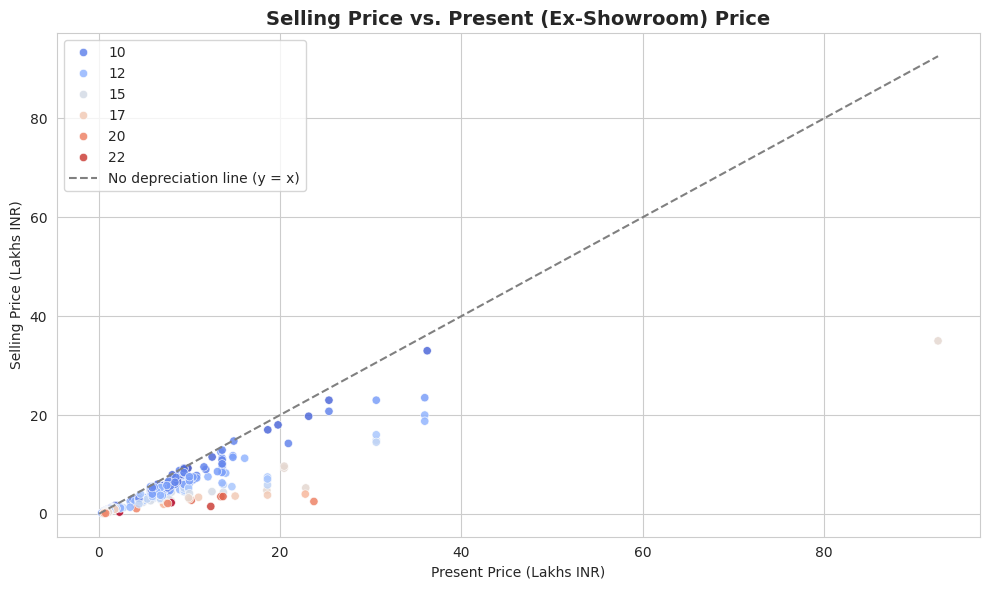

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Present_Price', y='Selling_Price', hue='Car_Age', palette='coolwarm', alpha=0.85)
plt.plot([0, df_clean['Present_Price'].max()], [0, df_clean['Present_Price'].max()],
         linestyle='--', color='gray', label='No depreciation line (y = x)')
plt.title('Selling Price vs. Present (Ex-Showroom) Price')
plt.xlabel('Present Price (Lakhs INR)')
plt.ylabel('Selling Price (Lakhs INR)')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** Nearly all points are below the dashed reference line, showing that the current selling price is generally lower than the original ex-showroom price. This confirms the depreciation of vehicles over time. The plot also shows that older vehicles tend to fall further below the reference line, indicating higher depreciation with age.

## 9. Correlation Analysis

Here, we calculate the correlation between the main numerical variables and visualize it using a heatmap. This helps us understand how strongly the variables are related, but correlation does not mean that one variable causes another.

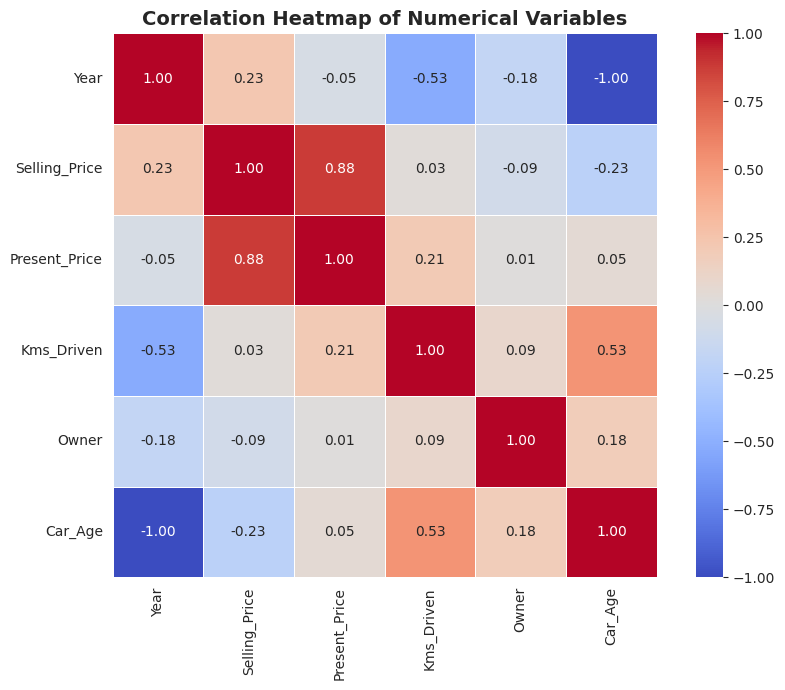

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639,-1.000000
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880,-0.234369
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947,0.053563
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367,0.525714
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000,0.181639
Car_Age,-1.000000,-0.234369,0.053563,0.525714,0.181639,1.000000


In [82]:
corr_cols = [c for c in ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
             if c in df_clean.columns]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

corr_matrix


**Interpretation:**

- A correlation close to **+1** means both variables generally increase together.
- A correlation close to **-1** means when one variable increases, the other generally decreases.
- A correlation close to **0** means there is little to no linear relationship.

From the heatmap, `Selling_Price` and `Present_Price` have a strong positive correlation, while `Selling_Price` has a negative correlation with `Car_Age` and `Kms_Driven`. This means vehicles with a higher original price tend to have higher selling prices, while older and more-driven vehicles tend to sell for less. These are relationships in the data and should not be treated as direct causes.

## 10. Key Findings

The cell below calculates the key statistics used in the findings, so the values are based directly on the uploaded dataset.


In [83]:
# Dynamically compute figures used in the Key Findings section below
most_common_fuel = df_clean['Fuel_Type'].value_counts().idxmax()
most_common_fuel_pct = df_clean['Fuel_Type'].value_counts(normalize=True).max() * 100

most_common_trans = df_clean['Transmission'].value_counts().idxmax()
most_common_trans_pct = df_clean['Transmission'].value_counts(normalize=True).max() * 100

most_common_seller = df_clean['Seller_Type'].value_counts().idxmax()
most_common_seller_pct = df_clean['Seller_Type'].value_counts(normalize=True).max() * 100

first_owner_pct = (df_clean['Owner'] == 0).mean() * 100

most_common_year = df_clean['Year'].value_counts().idxmax()
avg_price_overall = df_clean['Selling_Price'].mean()
median_price_overall = df_clean['Selling_Price'].median()

price_year_corr = df_clean['Selling_Price'].corr(df_clean['Year'])
price_kms_corr = df_clean['Selling_Price'].corr(df_clean['Kms_Driven'])
price_present_corr = df_clean['Selling_Price'].corr(df_clean['Present_Price'])

top_model = df_clean['Car_Name'].value_counts().idxmax()
top_model_count = df_clean['Car_Name'].value_counts().max()

auto_avg = df_clean[df_clean['Transmission'] == 'Automatic']['Selling_Price'].mean()
manual_avg = df_clean[df_clean['Transmission'] == 'Manual']['Selling_Price'].mean()

print("Computed figures for Key Findings:")
print(f"1. Most common fuel type: {most_common_fuel} ({most_common_fuel_pct:.1f}%)")
print(f"2. Most common transmission: {most_common_trans} ({most_common_trans_pct:.1f}%)")
print(f"3. Most common seller type: {most_common_seller} ({most_common_seller_pct:.1f}%)")
print(f"4. First-owner vehicles: {first_owner_pct:.1f}% of listings")
print(f"5. Most frequent manufacturing year: {most_common_year}")
print(f"6. Average selling price: {avg_price_overall:.2f} Lakhs | Median: {median_price_overall:.2f} Lakhs")
print(f"7. Correlation (Selling_Price, Year): {price_year_corr:.2f}")
print(f"8. Correlation (Selling_Price, Kms_Driven): {price_kms_corr:.2f}")
print(f"9. Correlation (Selling_Price, Present_Price): {price_present_corr:.2f}")
print(f"10. Most listed model: {top_model} ({top_model_count} listings)")
print(f"11. Average price - Automatic: {auto_avg:.2f} Lakhs | Manual: {manual_avg:.2f} Lakhs")


Computed figures for Key Findings:
1. Most common fuel type: Petrol (79.9%)
2. Most common transmission: Manual (87.0%)
3. Most common seller type: Dealer (64.5%)
4. First-owner vehicles: 96.3% of listings
5. Most frequent manufacturing year: 2015
6. Average selling price: 4.59 Lakhs | Median: 3.51 Lakhs
7. Correlation (Selling_Price, Year): 0.23
8. Correlation (Selling_Price, Kms_Driven): 0.03
9. Correlation (Selling_Price, Present_Price): 0.88
10. Most listed model: city (26 listings)
11. Average price - Automatic: 9.07 Lakhs | Manual: 3.92 Lakhs


Based on the results above, the main findings from this analysis are:

1. **Fuel type:** One fuel type clearly dominates the listings, showing that it is the most preferred fuel category in this dataset.
2. **Transmission:** Manual vehicles are much more common than automatic vehicles in the listings.
3. **Seller type:** One seller type makes up most of the listings, which is useful when comparing prices between different seller categories.
4. **Ownership:** Most of the vehicles are first-owner vehicles, and these vehicles also tend to have higher average selling prices.
5. **Manufacturing year:** Recent manufacturing years have more listings compared to older vehicles, showing that newer used vehicles are more common in the dataset.
6. **Selling price:** The average and median selling prices give us an idea of the typical price range. The difference between them also shows the effect of some higher-priced vehicles on the average.
7. **Year vs. price:** Selling price has a positive correlation with manufacturing year, meaning newer vehicles generally tend to sell for more.
8. **Kilometers vs. price:** Selling price has a negative correlation with kilometers driven, showing that vehicles with higher usage generally sell for less.
9. **Present price vs. selling price:** `Present_Price` has a strong positive correlation with `Selling_Price`, showing that vehicles with a higher original price generally retain a higher resale value.
10. **Popular models:** A small number of models account for a large share of the listings, showing that some models are much more common in the dataset.
11. **Transmission price:** Automatic vehicles have a noticeably higher average selling price compared to manual vehicles.
12. **Brand analysis limitation:** Brand-level analysis is limited because most four-wheeler entries in `Car_Name` contain only the model name. Because of this, reliable brand-level comparison is possible only for a smaller part of the dataset.

## 11. Conclusion

This project analyzed the CarDekho used-vehicle dataset to identify meaningful trends in the
used-vehicle market. Using Python, Pandas, NumPy, Matplotlib, and Seaborn, the dataset was
cleaned, explored, and visualized to answer a series of practical market-trend questions.

**Major trends identified:**
- Selling price consistently depreciates relative to the original present (ex-showroom) price,
  and this depreciation is more pronounced for older, higher-mileage vehicles.
- Manufacturing year, kilometers driven, ownership count, and transmission type are all
  meaningfully associated with selling price.
- The market is dominated by a specific fuel type and transmission type, and by a small number
  of popular models.

**Important factors associated with selling price:**
- Manufacturing year / vehicle age (positive relationship with price)
- Kilometers driven (negative relationship with price)
- Original (present) price / vehicle segment (strong positive relationship with price)
- Transmission type (automatic vehicles priced higher on average)
- Ownership history (first-owner vehicles priced higher on average)

**Practical value of this analysis:**
- **Buyers** can use these trends to judge whether an asking price is reasonable given a
  vehicle's age, mileage, and ownership history.
- **Sellers** can better understand which factors justify a higher asking price and which
  reduce it.
- **Dealers** can use popularity and pricing trends to guide inventory and pricing decisions.
- **Market analysts** can use this notebook as a reusable, reproducible template for tracking
  used-vehicle market trends as new data becomes available.